[<img src="https://gitlab.irit.fr/toc/etu-n7/controle-optimal/-/raw/master/ressources/Logo-toulouse-inp-N7.png" alt="N7" height="100"/>](https://gitlab.irit.fr/toc/etu-n7/controle-optimal)

<div style="width:90%;
            margin:10px;
            padding:8px;
            background-color:#FAA299;
            border:2px solid #BF381B;
            border-radius:20px;
            font-weight:bold;
            font-size:1em;"> <!-- il faut laisser une ligne vide après celle-ci -->

* Nom : BERBESSOU
* Prénom : Thomas
* Groupe : B1
</div>

# Transfert orbital

Ce sujet (ou TP-projet) est à rendre (voir la date sur moodle et les modalités du rendu) et sera évalué pour faire partie de la note finale de la matière Contrôle Optimal.

<div style="width:90%;
            margin:10px;
            padding:8px;
            background-color:#afa;
            border:2px solid #bbffbb;
            border-radius:20px;
            font-weight:bold;
            font-size:1.5em;
            text-align:center;">
Transfert orbital à temps minimal
</div>


On considère le problème du transfert d'un satellite d'une orbite initiale à l'orbite géostationnaire à temps minimal. Ce problème s'écrit comme un problème de contrôle optimal sous la forme

$$
\left\lbrace
\begin{array}{l}
    \min J(x, u, t_f) = t_f \\[1.0em]
    \ \ \dot{x}_{1}(t) = ~ x_{3}(t)  \\[0.5em]
    \ \ \dot{x}_{2}(t) = ~ x_{4}(t)  \\[0.5em]
    \ \ \dot{x}_{3}(t) =  -\dfrac{\mu\, x_{1}(t)}{r^{3}(x(t))} + u_{1}(t)  \\[1em]
    \ \ \dot{x}_{4}(t) =  -\dfrac{\mu\, x_{2}(t)}{r^{3}(x(t))} + u_{2}(t), ~~ ||u(t)|| \leq \gamma_\mathrm{max}, ~~ t \in [0,t_f] ~~ \text{p.p.}, ~~ u(t) = (u_1(t),u_2(t)),  \\[1.5em]
    \ \ x_{1}(0)=x_{0,1}, ~~ x_{2}(0)=x_{0,2}, ~~ x_{3}(0)=x_{0,3}, ~~ x_{4}(0)=x_{0,4}, \\[1em]
    \ \ r(x(t_f)) = r_{f}, ~~ x_{3}(t_f)=-\sqrt{\dfrac{\mu}{r_{f}^{3}}}x_{2}(t_f), ~~ x_{4}           (t_f)= \sqrt{\dfrac{\mu}{r_{f}^{3}}}x_{1}(t_f), \\
\end{array}
\right.
$$

avec $r(x)=\sqrt{x_{1}^{2}+x_{2}^{2}}$.
Les unités choisies sont le kilomètre pour les distances et l'heure pour les  temps. On donne les paramètres suivants :
 
$$
\mu=5.1658620912 \times 10^{12} \ \mathrm{km}^{3}.\mathrm{h}^{-2}, \quad r_{f} = 42165 \ \mathrm{km}.
$$

Le paramètre $\gamma_\mathrm{max}$ dépend de la poussée maximale $F_\mathrm{max}$ suivant la relation :

$$
\gamma_\mathrm{max} = \frac{F_\mathrm{max}\times 3600^2}{m} 
$$

où m est la masse du satellite qu'on fixe à $m=2000\ \mathrm{kg}$.

### Résolution via du tir simple indirect

In [ ]:
using DifferentialEquations, NLsolve, ForwardDiff, Plots, LinearAlgebra
include("utils.jl"); # fonctions utilitaires

[ Info: Precompiling DifferentialEquations [0c46a032-eb83-5123-abaf-570d42b7fbaa]
┌ Warning: Backwards compatability support of the new return codes to Symbols will be deprecated with the Julia v1.9 release. Please see https://docs.sciml.ai/SciMLBase/stable/interfaces/Solutions/#retcodes for more information
└ @ SciMLBase ~/.julia/packages/SciMLBase/QqtZA/src/retcodes.jl:355
┌ Warning: Backwards compatability support of the new return codes to Symbols will be deprecated with the Julia v1.9 release. Please see https://docs.sciml.ai/SciMLBase/stable/interfaces/Solutions/#retcodes for more information
└ @ SciMLBase ~/.julia/packages/SciMLBase/QqtZA/src/retcodes.jl:355
┌ Warning: Backwards compatability support of the new return codes to Symbols will be deprecated with the Julia v1.9 release. Please see https://docs.sciml.ai/SciMLBase/stable/interfaces/Solutions/#retcodes for more information
└ @ SciMLBase ~/.julia/packages/SciMLBase/QqtZA/src/retcodes.jl:355
┌ Warning: Backwards compatabi

In [ ]:
# Les constantes du pb
x0     = [-42272.67, 0, 0, -5796.72] # état initial
μ      = 5.1658620912*1e12
rf     = 42165
F_max  = 100
γ_max  = F_max*3600^2/(2000*10^3)
t0     = 0
rf3    = rf^3
α      = sqrt(μ/rf3);

✏️ **_Question 1:_**
    
1. Donner le pseudo-hamiltonien associé au problème de contrôle optimal.
2. Donner le pseudo système hamiltonien
$$
    \vec{H}(x, p, u) = \left(\frac{\partial H}{\partial p}(x, p, u), 
    -\frac{\partial H}{\partial x}(x, p, u) \right).
$$
3. Calculer le contrôle maximisant. On supposera que $(p_3, p_4)\neq (0,0)$.

**Réponse** (double cliquer pour modifier le texte)

<div style="width:90%;
            margin:10px;
            padding:20px;
            background-color:#CFF3F7;
            border:2px solid #063970;
            border-radius:20px;
            font-weight:bold;
            font-size:1em;"> <!-- il faut laisser une ligne vide après celle-ci -->
1.
$$
    H(x,p,u) = p_1x_3 + p_2x_4 - p_3\frac{\mu x_1}{r³(x)}+u_1 - p_4\frac{\mu x_2}{r³(x)}+u_2
$$
2.
$$
{\large
\left\lbrace
\begin{array}{l}
\frac{\partial H}{\partial p}(x, p, u) =  \left(x_3,x_4,-\frac{\mu x_1}{r³(x)}+u_1, -\frac{\mu x_2}{r³(x)}+u_2 \right)\\
-\frac{\partial H}{\partial x}(x, p, u) =\left( \frac{p_3\mu\, \left(r²(x)-3 x_1²\right)}{r⁵(x)} -\frac{3 \mu p_4x_1x_2}{r⁵(x)}, \frac{p_4\mu\, \left(r²(x)-3 x_2²\right)}{r⁵(x)} - \frac{3 \mu p_3x_1x_2}{r⁵(x)}, -p_1, -p_2 \right)
\end{array}
\right.
}
$$
3.
$$
{\large
control(p) = \frac{\gamma_{max}}{\sqrt{p_3^2 + p_4^2}}
\left(
\begin{array}{c}
p_3\\
p_4
\end{array}
\right)
}
$$

</div>

✏️ **_Question 2:_** Compléter le code suivant contenant le pseudo-hamiltonien, le pseudo système hamiltonien et le contrôle maximisant.

In [3]:
#####
##### A COMPLETER

# pseudo-Hamiltonien
function H(x, p, u)
    r = sqrt(x[1]^2 + x[2]^2)
    h = p[1]*x[3] + p[2]*x[4] + p[3]*((-μ*x[1])/r^3 + u[1]) +p[4]*((-μ*x[2]/r^3) + u[2])
    return h
end

# pseudo système hamiltonien
function Hv(x, p, u)
    n     = size(x, 1)
    r     = sqrt(x[1]^2+x[2]^2)
    dx    = zeros(eltype(x), n)
    dp    = zeros(eltype(x), n)
    
    dp[1] = p[3]*μ*( (r^2 - 3*x[1]^2)/r^5 ) - (3*μ*p[4]*x[2]*x[1])/r^5
    dp[2] = p[4]*μ*( (r^2 - 3*x[2]^2)/r^5 ) - (3*μ*p[3]*x[2]*x[1])/r^5
    dp[3] = -p[1]
    dp[4] = -p[2]
    
    dx[1] = x[3]
    dx[2] = x[4]
    dx[3] = -(μ*x[1])/r^3 + u[1]
    dx[4] = -(μ*x[2])/r^3 + u[2]
    
    return dx, dp
end

# Contrôle maximisant
function control(p)
    u    = γ_max*(1/sqrt(p[3]^2 + p[4]^2))*[p[3], p[4]]
    return u
end

#####
##### FIN A COMPLETER

# flot hamiltonien pour le calcul des extrémales
f = Flow((x, p) -> Hv(x, p, control(p)));

LoadError: UndefVarError: `Flow` not defined

On note 
$
    \alpha := \sqrt{\frac{\mu}{r_f^3}}.
$
La condition terminale peut se mettre sous la forme $c(x(t_f)) = 0$, avec $c \colon \mathbb{R}^4 \to \mathbb{R}^3$.

✏️ **_Question 3:_** Donner l'expression de $c(x)$.

**Réponse** (double cliquer pour modifier le texte)

<div style="width:90%;
            margin:10px;
            padding:20px;
            background-color:#CFF3F7;
            border:2px solid #063970;
            border-radius:20px;
            font-weight:bold;
            font-size:1em;"> <!-- il faut laisser une ligne vide après celle-ci -->

$$
c(x) = \left( r²(x)-r_f², x_3 + \alpha x_2, x_4-\alpha x_1\right)
$$
</div>

Le temps final étant libre, on a la condition au temps final 

$$
    H(x(t_f), p(t_f), u(t_f)) = -p^0 = 1. \quad \text{(on se place dans le cas normal)}
$$

De plus, la condition de transversalité 

$$
p(t_f) = c'(x(t_f))^T \lambda, ~~ \lambda \in \mathbb{R}^3,
$$

conduit à la relation suivante (où $\lambda$ n'apparaît plus)

$$
\Phi(x(t_f), p(t_f)) := x_2(t_f) \Big( p_1(t_f) + \alpha\, p_4(t_f) \Big) - x_1(t_f) \Big( p_2(t_f) - \alpha\, p_3(t_f) \Big) = 0.
$$

En considérant la condition aux limites, la condition finale sur le pseudo-hamiltonien et la condition de transversalité, la fonction de tir simple est donnée par 

\begin{equation*}
    \begin{array}{rlll}
        S \colon    & \mathbb{R}^5          & \longrightarrow   & \mathbb{R}^5 \\
        & (p_0, t_f)      & \longmapsto       &
        S(p_0, t_f) := \begin{pmatrix}
            c(x(t_f, x_0, p_0)) \\[0.5em]
            \Phi(z(t_f, x_0, p_0)) \\[0.5em]
            H(z(t_f, x_0, p_0), u(z(t_f, x_0, p_0))) - 1
        \end{pmatrix}
    \end{array}
\end{equation*}

où $z(t_f, x_0, p_0)$ est la solution au temps $t_f$ du pseudo système hamiltonien bouclé par
le contrôle maximisant, partant au temps $t_0=0$ du point $(x_0, p_0)$. On rappelle que l'on note
$z=(x, p)$.

✏️ **_Question 4:_** Compléter le code suivant de la fonction de tir.

In [5]:
#####
##### A COMPLETER

# Fonction de tir
function shoot(p0, tf)
    x,p = f(t0,x0,p0,tf)
    s = zeros(eltype(p0), 5)
    r = sqrt(x[1]^2 + x[2]^2)
    
    s[1] = r - rf #ne pas mettre au carre parce-que valeur rop grande 
    s[2] = x[3] + α*x[2]
    s[3] = x[4] - α*x[1]
    s[4] = x[2]*(p[1] + α*p[4]) - x[1]*(p[2]-α*p[3])
    s[5] = H(x,p,control(p)) - 1
    
    return s

end;

✏️ **_Question 5:_** Expliquer simplement ce que fait le code suivant.

**Réponse** (double cliquer pour modifier le texte)

<div style="width:90%;
            margin:10px;
            padding:20px;
            background-color:#CFF3F7;
            border:2px solid #063970;
            border-radius:20px;
            font-weight:bold;
            font-size:1em;"> <!-- il faut laisser une ligne vide après celle-ci -->

Le code suivant initialise la fonction de tir puis résout le sytème $shoot(p_0, t_f) = 0$. 
Enfin, le code renvoie la solution au système si l'algorithme converge.
</div>

In [6]:
# Itéré initial
y_guess = [1.0323e-4, 4.915e-5, 3.568e-4, -1.554e-4, 13.4]   # pour F_max = 100N

# Jacobienne de la fonction de tir
foo(y)  = shoot(y[1:4], y[5])
jfoo(y) = ForwardDiff.jacobian(foo, y)

# Résolution de shoot(p0, tf) = 0
nl_sol = nlsolve(foo, jfoo, y_guess; xtol=1e-8, method=:trust_region, show_trace=true);

# On récupère la solution si convergence
if converged(nl_sol)
    p0_sol_100 = nl_sol.zero[1:4]
    tf_sol_100 = nl_sol.zero[5]
    println("\nFinal solution:\n", nl_sol.zero)
else
    error("Not converged")
end

Iter     f(x) inf-norm    Step 2-norm 
------   --------------   --------------
     0     4.208247e+02              NaN
     1     3.419791e+00     3.507495e-03
     2     8.493479e-02     3.222915e-04
     3     4.217345e-07     3.247983e-06
     4     3.710738e-10     2.965042e-10

Final solution:
[0.0001032311891361884, 4.892642781236139e-5, 0.0003567967293906531, -0.0001553613886285998, 13.40318195714933]


In [8]:
# Fonction d'affichage d'une solution
function plot_solution(p0, tf)

    # On trace l'orbite de départ et d'arrivée
    gr(dpi=300, size=(500,400), thickness_scaling=1)
    r0        = norm(x0[1:2])
    v0        = norm(x0[3:4])
    a         = 1.0/(2.0/r0-v0*v0/μ)
    t1        = r0*v0*v0/μ - 1.0;
    t2        = (x0[1:2]'*x0[3:4])/sqrt(a*μ);
    e_ellipse = norm([t1 t2])
    p_orb     = a*(1-e_ellipse^2);
    n_theta   = 101
    Theta     = range(0, stop=2*pi, length=n_theta)
    X1_orb_init = zeros(n_theta)
    X2_orb_init = zeros(n_theta)
    X1_orb_arr  = zeros(n_theta)
    X2_orb_arr  = zeros(n_theta)

    # Orbite initiale
    for  i in 1:n_theta
        theta = Theta[i]
        r_orb = p_orb/(1+e_ellipse*cos(theta));
        X1_orb_init[i] = r_orb*cos(theta);
        X2_orb_init[i] = r_orb*sin(theta);
    end

    # Orbite d'arrivée
    for  i in 1:n_theta
        theta = Theta[i]
        X1_orb_arr[i] = rf*cos(theta) ;
        X2_orb_arr[i] = rf*sin(theta);
    end;

    # Calcul de la trajectoire
    ode_sol  = f((t0, tf), x0, p0)
    t  = ode_sol.t
    x1 = [ode_sol[1, j] for j in 1:size(t, 1) ]
    x2 = [ode_sol[2, j] for j in 1:size(t, 1) ]
    u  = zeros(2, length(t))

    for j in 1:size(t, 1)
        u[:,j] = control(ode_sol[5:8, j])
    end

    px = plot(x1, x2, color=:red, legend=:best, label="Trajectoire",
        border=:none, size = (800,400), aspect_ratio=:equal)
    plot!(px, X1_orb_init, X2_orb_init, color=:green, label="Orbite initiale")
    plot!(px, X1_orb_arr, X2_orb_arr, color=:blue, label="Orbite d'arrivée")
    plot!(px, [x0[1]], [x0[2]], seriestype=:scatter, color=:green, markersize = 5, label="Départ")
    xf = ode_sol[1:2, end]
    plot!(px, [xf[1]], [xf[2]], seriestype=:scatter, color=:red, markersize = 5, label="Arrivée")
    plot!(px, [0.0], [0.0], color = :blue, seriestype=:scatter, markersize = 25, label="Terre")

    pu1 = plot(t, u[1,:], color=:red, label="u₁(t)", legend=:best)
    pu2 = plot(t, u[2,:], color=:red, label="u₂(t)", legend=:best)

    display(plot(pu1, pu2, layout = (1,2), size = (800,400)))
    display(px)
    
end;

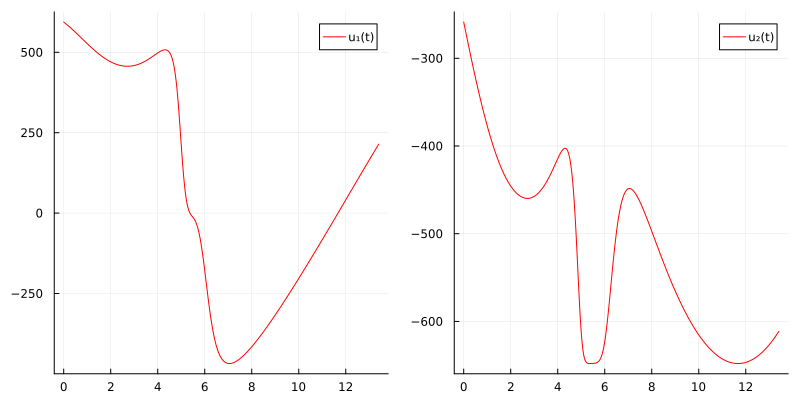

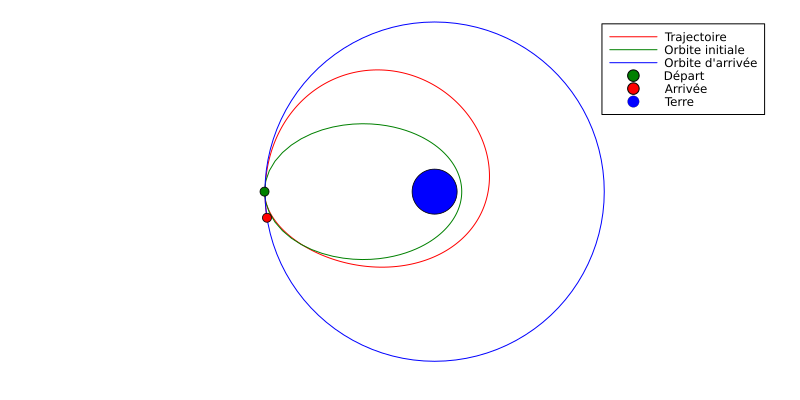

In [9]:
# On affiche la solution pour Fmax = 100
plot_solution(p0_sol_100, tf_sol_100)

✏️ **_Question 6:_** Que vaut le temps final $t_f$ (à 5 digits près) ? Combien de révolutions complètes autour de la Terre a réalisé le satellite.

**Réponse** (double cliquer pour modifier le texte)

<div style="width:90%;
            margin:10px;
            padding:20px;
            background-color:#CFF3F7;
            border:2px solid #063970;
            border-radius:20px;
            font-weight:bold;
            font-size:1em;"> <!-- il faut laisser une ligne vide après celle-ci -->

$$
t_f = 13.40318
$$
    
Le satellite réalise une révolution complète autour de la terre pendant sa transition entre les deux orbites.
</div>

### Etude du temps de transfert en fonction de la poussée maximale

✏️ **_Question 7:_** 

* A l'aide de ce que vous avez fait précédemment, déterminer $t_f$ (attention, penser à bien itinialiser la
méthode de tir) pour
    
$$
    F_\mathrm{max} \in \{100, 90, 80, 70, 60, 50, 40, 30, 20 \}.
$$
    
* Tracer ensuite $t_f$ en fonction de $F_\mathrm{max}$ et commenter le résultat.

**Réponse** (double cliquer pour modifier le texte et donner votre commentaire)

<div style="width:90%;
            margin:10px;
            padding:20px;
            background-color:#CFF3F7;
            border:2px solid #063970;
            border-radius:20px;
            font-weight:bold;
            font-size:1em;"> <!-- il faut laisser une ligne vide après celle-ci -->


Les $t_f$ sont :
    
$$
\begin{array}{l|c}
F_{Max} & t_f \\
\hline 
100 & 13.40318 \\
90 & 13.966407 \\
80 & 14.731379 \\
70 & 16.245635 \\
60 & 19.548303 \\
50 & 23.620584 \\
40 & 30.024372 \\
30 & 39.608227 \\
20 & 59.855166\\
\end{array}
$$

Le graphique ci-dessous montre que le temps nécessaire pour effectuer le changement d'orbite augmente avec la diminution de $F_{MAX}$. Cela est cohérent avec le fait que le contrôle optimal pour un $F_{MAX}$ donné est comprise dans l'ensemble des contrôles possibles pour un $F_{MAX}'>F_{MAX}$  
</div>

In [8]:
# Les différentes valeurs de poussées
F_max_span = range(100, stop=20, length=9);
γ_max_span = [F_max_span[j]*3600^2/(2000*10^3) for j in 1:size(F_max_span,1)];

In [9]:
# Solution calculée précédemment
y_guess = [p0_sol_100; [tf_sol_100]]

# Pour le stockage des solutions
tf_sols = zeros(length(γ_max_span))     # vecteur des temps de transfert
p0_sols = zeros(4, length(γ_max_span))  # matrice des co-états initiaux

#####
##### A COMPLETER

for j in 1:size(F_max_span,1)
    γ_max = γ_max_span[j]
    
    # Résolution de shoot(p0, tf) = 0
    nl_sol = nlsolve(foo, jfoo, y_guess; xtol=1e-8, method=:trust_region, show_trace=true);

    # On récupère la solution si convergence
    if converged(nl_sol)
        p0_sols[:,j] = nl_sol.zero[1:4]
        tf_sols[j] = nl_sol.zero[5]
        y_guess = nl_sol.zero
        println("\nFinal solution:\n", nl_sol.zero)
    else
        error("Not converged")
    end
end

Iter     f(x) inf-norm    Step 2-norm 
------   --------------   --------------

Final solution:
[0.0001032311891361884, 4.892642781236139e-5, 0.0003567967293906531, -0.0001553613886285998, 13.40318195714933]
Iter     f(x) inf-norm    Step 2-norm 
------   --------------   --------------
     0     6.007193e+02              NaN
     1     6.943510e+02     2.710505e-20
     2     6.943510e+02     0.000000e+00
     3     6.943510e+02     0.000000e+00
     4     5.391509e+02     4.742570e-01
     5     4.234815e+01     9.794729e-02
     6     8.881702e-01     8.918208e-03
     7     3.926165e-05     6.096356e-05
     8     1.891749e-10     2.140583e-08

Final solution:
[7.914298248246724e-5, 4.7750370607418976e-5, 0.0003482203140858575, -0.0003054699858049872, 13.966407074759156]
Iter     f(x) inf-norm    Step 2-norm 
------   --------------   --------------
     0     7.229853e+02              NaN
     1     1.471842e+03     5.421011e-20
     2     1.471842e+03     0.000000e+00
     3   

    72     5.731486e+01     5.415027e-01
    73     2.112281e-01     1.386691e-04
    74     7.695447e-05     3.846405e-04
    75     2.058368e-08     5.902500e-08
    76     5.071342e-09     9.947648e-14

Final solution:
[-0.001361571112437414, -7.34989697985752e-6, -5.3599237082745606e-5, -0.008582713096396147, 59.85516689032152]


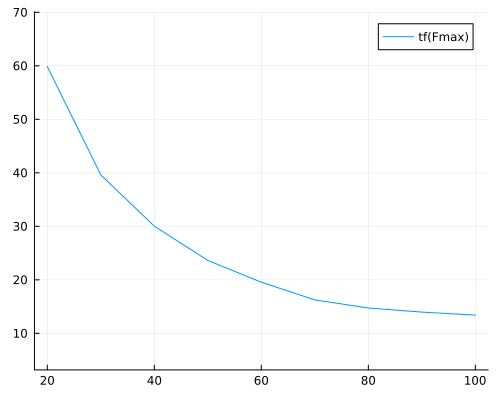

In [10]:
# Affichage de tf en fonction de la poussée maximale
plot(F_max_span, tf_sols, aspect_ratio=:equal, legend=:best, label="tf(Fmax)")

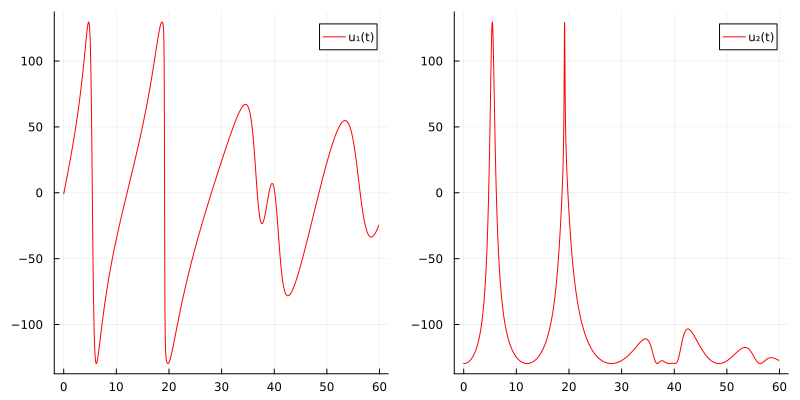

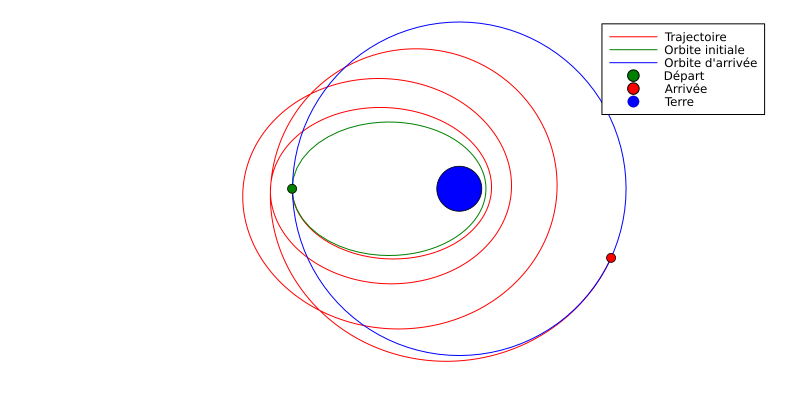

In [12]:
# Plots sol pour F_max = 20N
i = 9
γ_max = γ_max_span[i]
plot_solution(p0_sols[:, i], tf_sols[i])

### Animation

Juste pour s'amuser

In [13]:
include("space.jl"); using .Space

Fps     = 3
NFrame  = 100
Vitesse = 0.7574385139752596
Durée totale de la mission = 44.007972552636936 h


[ Info: Saved animation to /home/tberbess/Annee2/controle-optimal/tp/transfert-temps-min.gif


Plots.AnimatedGif("/home/tberbess/Annee2/controle-optimal/tp/transfert-temps-min.gif")
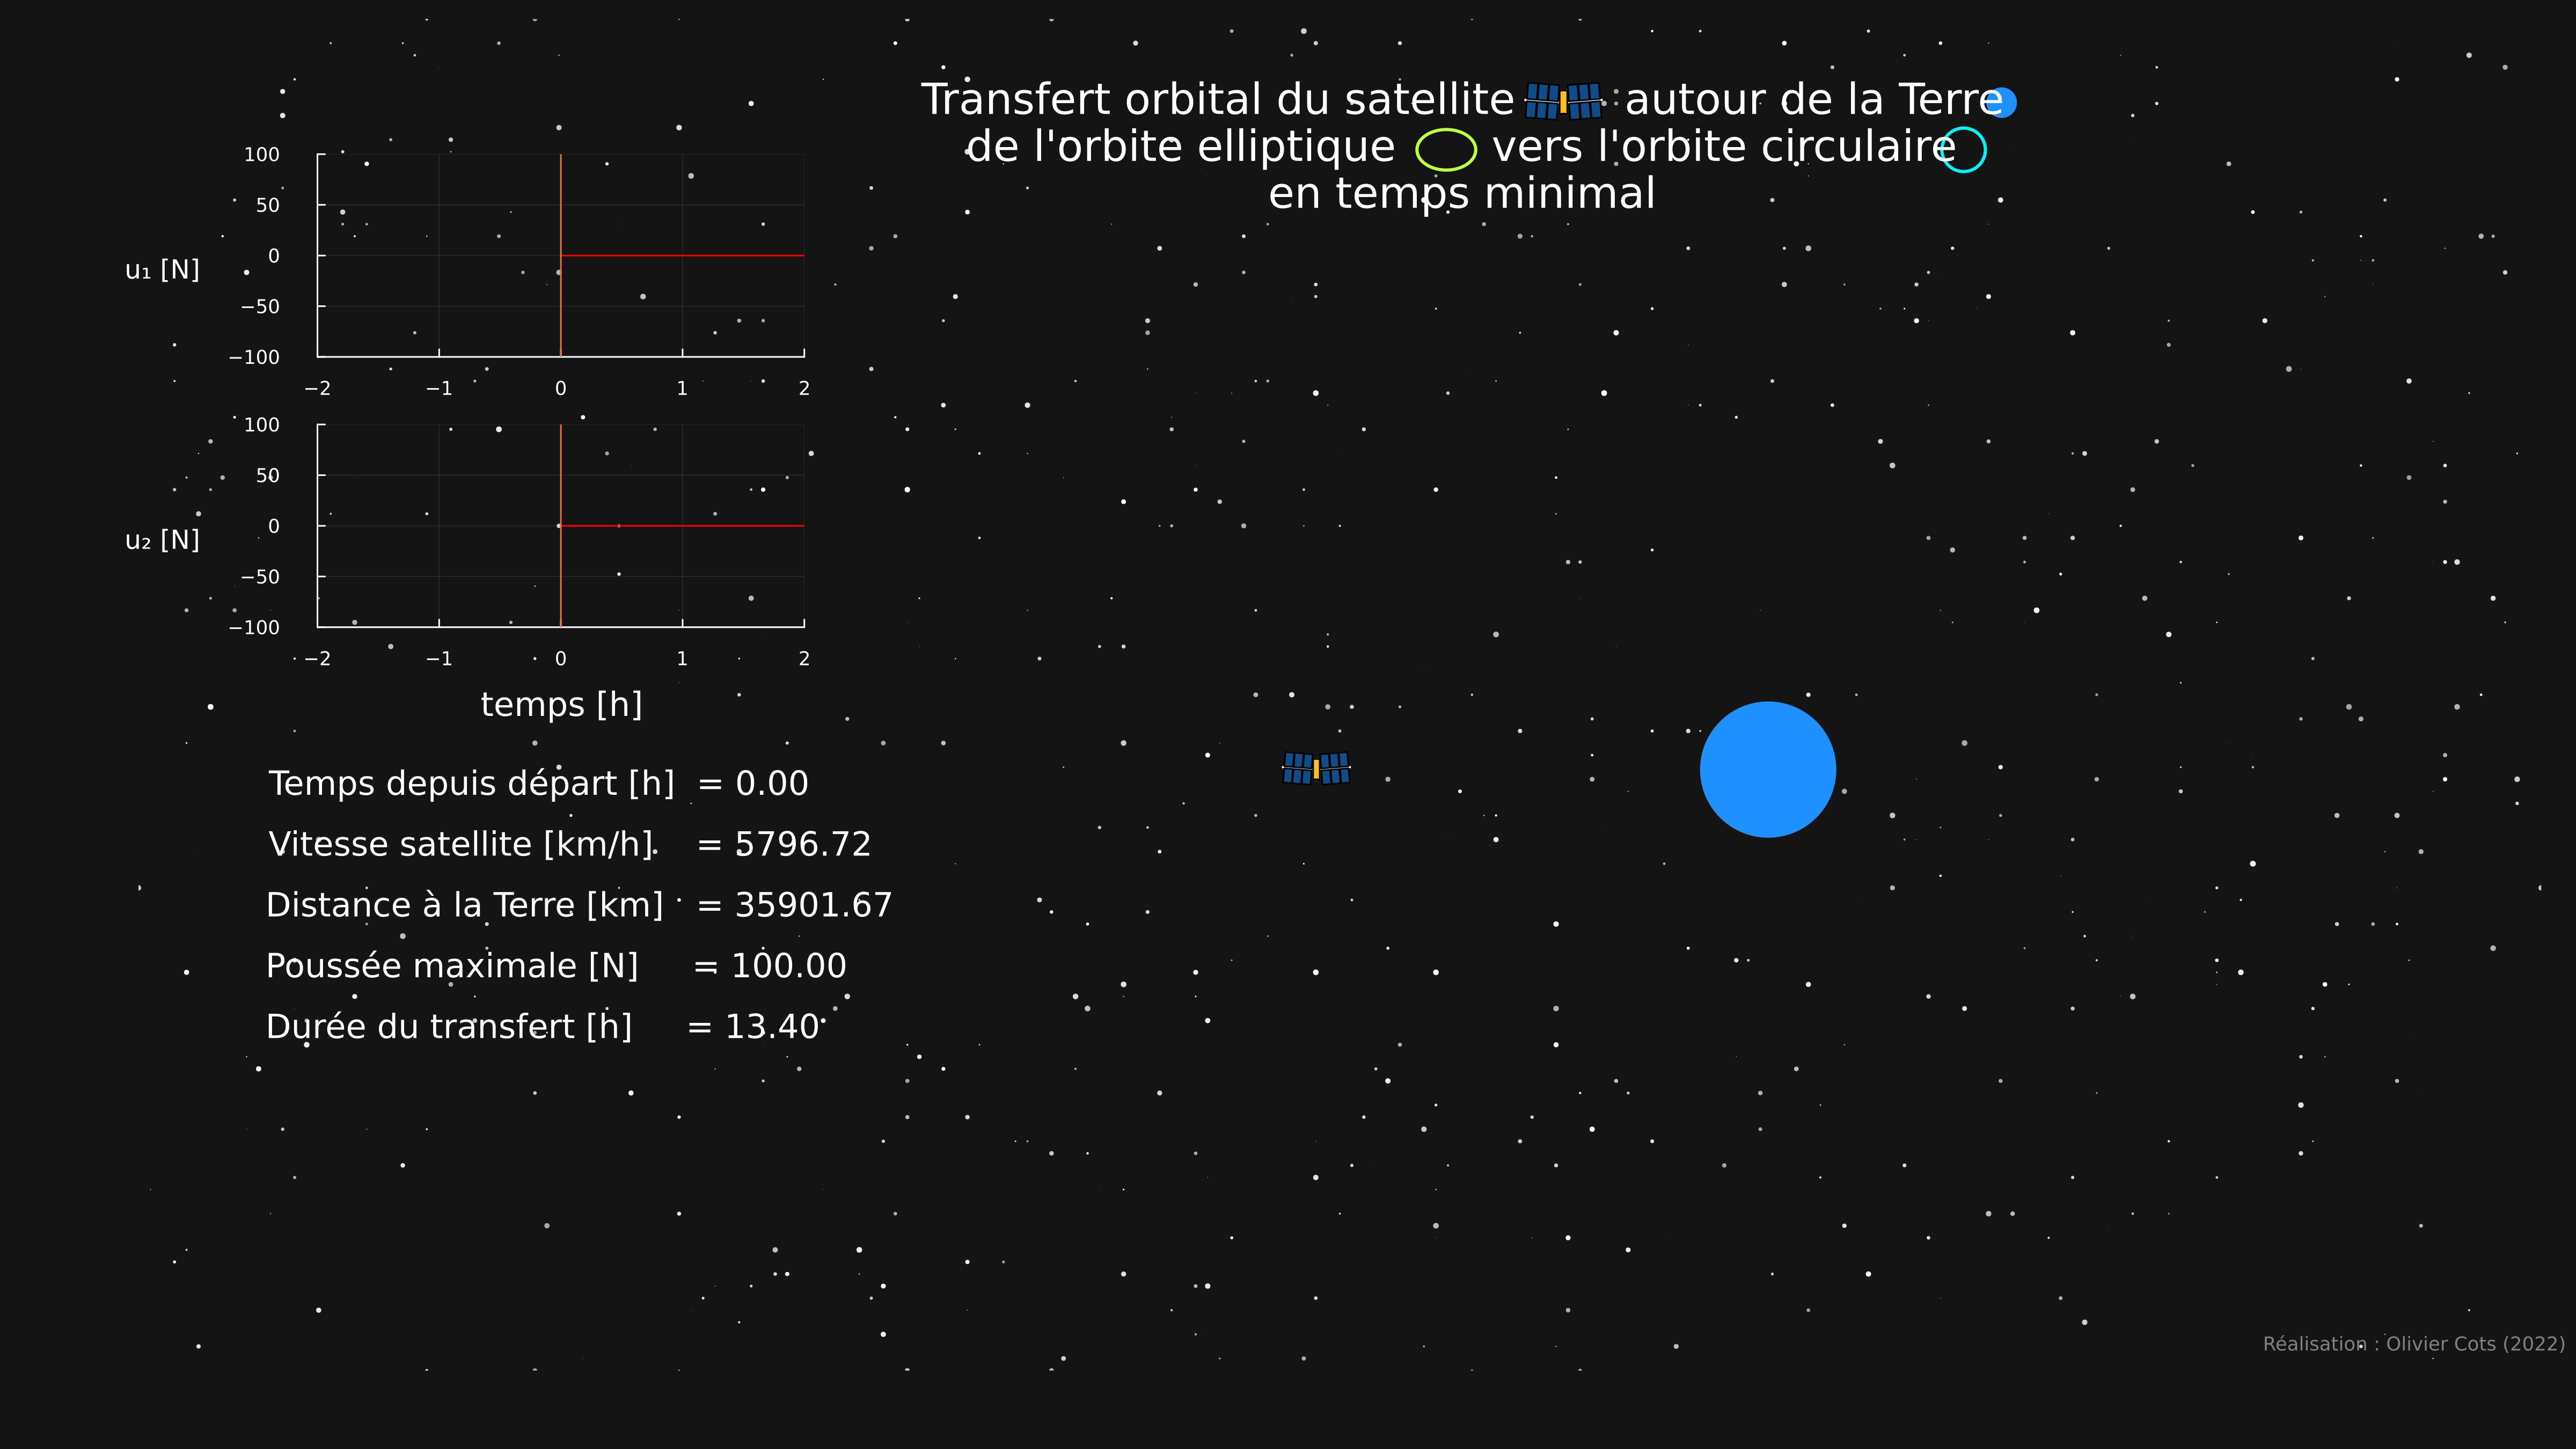

In [14]:
# solution choice
i = 1
γ_max = γ_max_span[i] # γ_max must be updated for the use of the flow

# animation
# nFrame = 100; d = 30; fps = floor(Int, nFrame/d) => 2 minutes and 30 seconds of computation
nFrame = 100; d = 30; fps = floor(Int, nFrame/d)
Space.animation(p0_sols[:, i], tf_sols[i], f, γ_max, nFrame=nFrame, fps=fps)

<div style="width:90%;
            margin:10px;
            padding:8px;
            background-color:#afa;
            border:2px solid #bbffbb;
            border-radius:20px;
            font-weight:bold;
            font-size:1.5em;
            text-align:center;">
Transfert orbital à consommation minimale
</div>

On considère maintenant le problème du transfert d'un satellite d'une orbite initiale à une orbite géostationnaire à temps final fixé en cherchant à minimiser la consommation de carburant. Ce problème s'écrit comme un problème de contrôle optimal sous la forme

$$
\left\lbrace
\begin{array}{l}
    \displaystyle \min J(x, u) = \int_{0}^{t_f} \Vert u(t)\Vert \mathrm{d}t \\[1.0em]
    \ \ \dot{x}_{1}(t) = ~ x_{3}(t)  \\[0.5em]
    \ \ \dot{x}_{2}(t) = ~ x_{4}(t)  \\[0.5em]
    \ \ \dot{x}_{3}(t) =  -\dfrac{\mu\, x_{1}(t)}{r^{3}(x(t))} + u_{1}(t)  \\[1em]
    \ \ \dot{x}_{4}(t) =  -\dfrac{\mu\, x_{2}(t)}{r^{3}(x(t))} + u_{2}(t), ~~ ||u(t)|| \leq \gamma_\mathrm{max}, ~~ t \in [0,t_f] ~~ \text{p.p.}, ~~ u(t) = (u_1(t),u_2(t)),  \\[1.5em]
    \ \ x_{1}(0)=x_{0,1}, ~~ x_{2}(0)=x_{0,2}, ~~ x_{3}(0)=x_{0,3}, ~~ x_{4}(0)=x_{0,4}, \\[1em]
    \ \ r(x(t_f)) = r_{f}, ~~ x_{3}(t_f)=-\sqrt{\dfrac{\mu}{r_{f}^{3}}}x_{2}(t_f), ~~ x_{4}           (t_f)= \sqrt{\dfrac{\mu}{r_{f}^{3}}}x_{1}(t_f). \\
\end{array}
\right.
$$

Toutes les constantes sont identiques au problème précédent. On considéra le problème avec $F_\mathrm{max} = 100$ et on prendre comme temps final : $t_f = 1.5 T^{100}_{\min}$, où $T^{100}_{\min}$ correspond au temps minimal solution du problème précédent pour $F_\mathrm{max} = 100$.

**Remarques importantes.** 

* On ne considèrera que des extrémales normales, c'est-à-dire $p^0 = -1$.
* Le problème a de la structure, le contrôle optimal est composé d'arcs où la poussée est nulle $u(t) = 0$ et où la poussée est maximale $\Vert u(t)\Vert = \gamma_\mathrm{max}$.
* Vous devrez dans un premier temps résoudre le problème avec le coût suivant ce qui permet de le régulariser et ainsi d'utiliser une méthode de tir simple :

$$
\int_{0}^{t_f} \left( \Vert u(t)\Vert - \varepsilon \left( \ln(\Vert u(t)\Vert) + \ln(\gamma_\mathrm{max}-\Vert u(t)\Vert) \right) \right) \mathrm{d}t.
$$

✏️ **_Question 8:_** Résoudre via du tir simple le problème régularisé pour différentes valeurs de $\varepsilon$ suffisamment petites pour déterminer la structure optimale, en commençant avec $\varepsilon$ suffisamment grand pour faire converger la méthode de tir plus facilement.

In [52]:
#####
##### A COMPLETER
ϵ = 2
# pseudo-Hamiltonien
function H(x, p, u)
    r = sqrt(x[1]^2 + x[2]^2)
    h = p[1]*x[3] + p[2]*x[4] + p[3]*((-μ*x[1])/r^3 + u[1]) +p[4]*((-μ*x[2]/r^3) + u[2]) - norm(u) + ϵ*(log(norm(u)) + log(γ_max - norm(u)))
    return h
end

# pseudo système hamiltonien
function Hv(x, p, u)
    n     = size(x, 1)
    r     = sqrt(x[1]^2+x[2]^2)
    dx    = zeros(eltype(x), n)
    dp    = zeros(eltype(x), n)
    
    dp[1] = p[3]*μ*( (r^2 - 3*x[1]^2)/r^5 ) - (3*μ*p[4]*x[2]*x[1])/r^5
    dp[2] = p[4]*μ*( (r^2 - 3*x[2]^2)/r^5 ) - (3*μ*p[3]*x[2]*x[1])/r^5
    dp[3] = -p[1]
    dp[4] = -p[2]
    
    dx[1] = x[3]
    dx[2] = x[4]
    dx[3] = -(μ*x[1])/r^3 + u[1]
    dx[4] = -(μ*x[2])/r^3 + u[2]
    
    return dx, dp
end

# Contrôle maximisant
function control(p)
    normp = sqrt(p[3]^2 + p[4]^2)
    B = 2*ϵ + γ_max - normp*γ_max
    A = normp - 1
    C = -γ_max*ϵ
    normu1 = (-B + sqrt(B^2 - 4*A*C))/(2*A)
    normu2 = (-B - sqrt(B^2 - 4*A*C))/(2*A)
    
    if (normu1 < γ_max && normu1 > 0)
        normu = normu1
    elseif (normu2 < γ_max && normu2 > 0)
        normu = normu2
    else 
        normu = 0
    end
    
    M = -ϵ/normu^2 + ϵ/(normu*(γ_max-normu)) + 1/normu
    u1 = p[3]/M
    u2 = p[4]/M
    return [u1,u2]
end

#####
##### FIN A COMPLETER

# flot hamiltonien pour le calcul des extrémales
f = Flow((x, p) -> Hv(x, p, control(p)));

In [53]:
#####
##### A COMPLETER

# Fonction de tir
function shoot(p0)
    x,p = f(t0,x0,p0,1.5*tf_sol_100)
    s = zeros(eltype(p0), 4)
    r = sqrt(x[1]^2 + x[2]^2)
    
    s[1] = r - rf #ne pas mettre au carre parce-que valeur rop grande 
    s[2] = x[3] + α*x[2]
    s[3] = x[4] - α*x[1]
    s[4] = x[2]*(p[1] + α*p[4]) - x[1]*(p[2]-α*p[3])
    
    return s

end;

In [54]:
# Itéré initial
y_guess = [1.0323e-4, 4.915e-5, 3.568e-4, -1.554e-4]   # pour F_max = 100N

# Jacobienne de la fonction de tir
foo(y)  = shoot(y)
jfoo(y) = ForwardDiff.jacobian(foo, y)

# Résolution de shoot(p0, tf) = 0
nl_sol = nlsolve(foo, jfoo, y_guess; xtol=1e-8, method=:trust_region, show_trace=true);

# On récupère la solution si convergence
if converged(nl_sol)
    p0_sol_100 = nl_sol.zero[1:4]
    println("\nFinal solution:\n", nl_sol.zero)
else
    error("Not converged")
end

Iter     f(x) inf-norm    Step 2-norm 
------   --------------   --------------
     0     5.087288e+03              NaN
     1     5.028396e+03     9.453998e-04
     2     5.083975e+03     6.639355e-20
     3     5.072715e+03     2.710505e-20
     4     5.064259e+03     0.000000e+00
     5     5.024429e+03     0.000000e+00
     6     5.023047e+03     2.090111e-04
     7     5.040820e+03     2.710505e-20
     8     5.029124e+03     5.446126e-04
     9     5.025051e+03     0.000000e+00
    10     5.023775e+03     1.343125e-04
    11     5.030860e+03     8.309205e-04
    12     5.076415e+03     5.421011e-20
    13     5.036447e+03     5.587850e-20
    14     5.028500e+03     1.260672e-04
    15     5.029804e+03     1.694066e-21
    16     5.028983e+03     3.824170e-05
    17     5.028855e+03     0.000000e+00
    18     5.028845e+03     2.622032e-05
    19     5.029175e+03     1.826066e-05
    20     5.029082e+03     2.595410e-05
    21     5.029399e+03     1.886141e-05
    22     5.02931

   198     5.033387e+03     1.189178e-05
   199     5.033362e+03     6.245016e-06
   200     5.033379e+03     1.202556e-05
   201     5.033354e+03     6.307482e-06
   202     5.033371e+03     1.216196e-05
   203     5.033346e+03     6.373416e-06
   204     5.033363e+03     1.230102e-05
   205     5.033338e+03     6.443136e-06
   206     5.033355e+03     1.244278e-05
   207     5.033330e+03     6.516995e-06
   208     5.033347e+03     1.258724e-05
   209     5.033322e+03     6.595382e-06
   210     5.033338e+03     1.273444e-05
   211     5.033313e+03     6.678726e-06
   212     5.033329e+03     1.288438e-05
   213     5.033304e+03     6.767500e-06
   214     5.033320e+03     1.303706e-05
   215     5.033295e+03     6.862227e-06
   216     5.033333e+03     0.000000e+00
   217     5.033311e+03     1.360225e-05
   218     5.033285e+03     7.110333e-06
   219     5.033302e+03     1.370066e-05
   220     5.033275e+03     7.218375e-06
   221     5.033292e+03     1.386975e-05
   222     5.033

   398     2.898679e+03     0.000000e+00
   399     2.906773e+03     5.473232e-04
   400     2.879060e+03     6.593820e-04
   401     2.872293e+03     2.109641e-03
   402     2.854770e+03     2.930170e-03
   403     2.825274e+03     7.248439e-03
   404     2.754294e+03     1.322605e-02
   405     2.681159e+03     2.960461e-02
   406     2.597969e+03     6.011886e-02
   407     2.305876e+03     1.262144e-01
   408     2.112522e+03     1.398579e-17
   409     2.170746e+03     1.281800e-01
   410     3.261906e+03     7.152448e-18
   411     1.832303e+03     1.337358e-01
   412     1.294045e+04     1.430490e-17
   413     1.755110e+03     1.279916e-01
   414     8.326702e+03     1.551584e-17
   415     1.523513e+03     1.038562e-01
   416     1.004593e+03     1.821778e-01
   417     6.088846e+03     2.775558e-17
   418     2.421004e+03     2.775558e-17
   419     9.964053e+02     0.000000e+00
   420     8.154308e+02     4.180542e-02
   421     9.475391e+02     0.000000e+00
   422     7.277

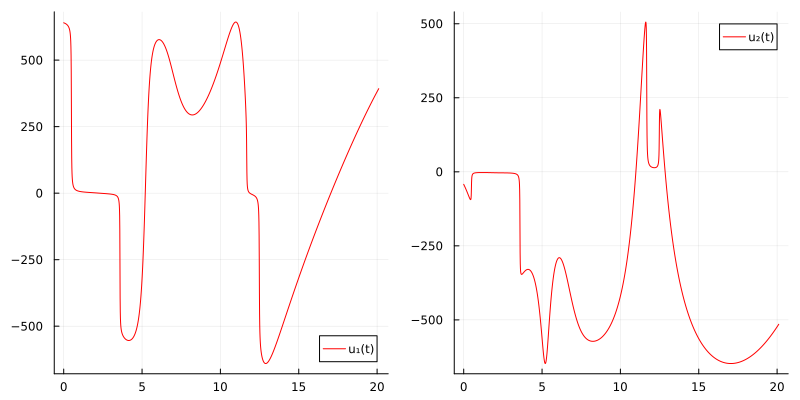

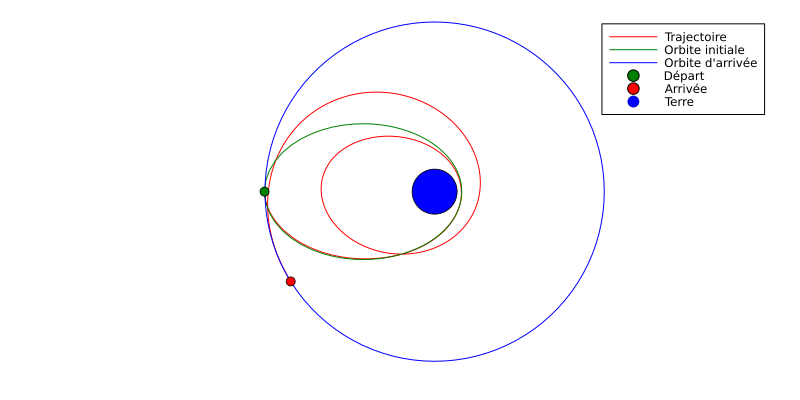

In [55]:
# On affiche la solution pour Fmax = 100
plot_solution(p0_sol_100, 1.5*tf_sol_100)

✏️ **_Question 9:_** Résoudre via du tir multiple le problème de transfert orbital à consommation minimale. Vous utilisez la structure obtenue précédemment et vous donnerez au solveur une bonne condition initiale à l'aide de la question précédente.